# Example use of HBQ in a mini-GRN generator

* Demonstrates a minimal Generative Refinement Network (https://arxiv.org/abs/2604.13030) using this Heirarchical Binary Quantizer.

In [1]:
import hierarchical_binary_quantization.hbq as hbq
import hierarchical_binary_quantization.misc.image_helpers as ih
import lpips
import math, random
import os
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import einx
import random
import torchvision
from torchvision import transforms
from datetime import datetime
import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
import hierarchical_binary_quantization.example_autoencoder as eae
from hierarchical_binary_quantization.misc.image_helpers import q_out_to_rgb
from hierarchical_binary_quantization.misc.checkpoint_helpers import save_checkpoint,load_checkpoint
from hierarchical_binary_quantization.example_autoencoder import ExampleAutoencoder, ExampleQuantizingAutoencoder
from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torch.utils.data import Dataset
import IPython.display as ipd
#autoencoder.post_quant())
from hierarchical_binary_quantization.hbq import tokens_to_bit_codes, bit_codes_to_quantized_latent
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
from PIL import Image
import numpy as np


In [2]:
dataset='fantasy'
device='cpu'
autoencoder_cp = 'checkpoints/good/2026-08-05_256_4_bd_96_ld_32_qd_8.pth'
batch_size = 128

## Unconditioned generation of the first bit.

In [3]:
def show_reconstructions(model, imgs):
    was_training = model.training
    model.eval()
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    if was_training:
        model.train()
    original = ih.tensor_to_pil(imgs[0])
    reconstruction = ih.tensor_to_pil(reconstructions[0])
    latent = ih.tensor_to_pil(q_out_to_rgb(aux.quant_info.quantized)[0])
    print(
        f"latent: μ={aux.latents.mean():.3f}  σ={aux.latents.std():.3f}"
    )
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
            f"unique tokens={unique} out of "
            f"{2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )
    h = ih.html_for_images([original, latent, reconstruction])
    return h, original, latent, reconstruction
    

In [4]:
cfg = ch.check_checkpoint(autoencoder_cp)['config']
autoencoder = ExampleQuantizingAutoencoder(**cfg)
load_checkpoint(autoencoder,None,autoencoder_cp)
autoencoder.eval()
autoencoder.to('cpu')
pass

🔄 Loading checkpoint from checkpoints/good/2026-08-05_256_4_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4), 'res_blocks': (1, 2, 3, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}
🔄 Loading checkpoint from checkpoints/good/2026-08-05_256_4_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4), 'res_blocks': (1, 2, 3, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}


## Bit predictor

In [5]:
class BitDataset(Dataset):
    def __init__(self, root, n_rounds=1, max_rounds=4):
        self.root = Path(root)
        self.n_rounds = n_rounds
        self.max_rounds = max_rounds
        self.files = sorted(self.root.rglob("*.npz"))
        print(f"Found {len(self.files)} cached latents.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        bit_codes = torch.from_numpy(data["bit_codes"].astype(np.int64))  # (L, H, W)
        # return all bits up to n_rounds, not just the nth bit
        bits = (bit_codes >> (self.max_rounds - self.n_rounds)) & ((1 << self.n_rounds) - 1)
        return bits.permute(1, 2, 0)                           # (H, W, L), values 0..2^n_rounds-1

In [15]:
autoencoder.config

HBQAutoencoderConfig(in_channels=3, base_dim=96, channel_multipliers=(1, 2, 3, 4), res_blocks=(1, 2, 3, 3), latent_dim=32, quant_dim=8, n_rounds=4)

Found 12814 cached latents.
torch.Size([1, 32, 32, 8]) tensor(1) tensor([0, 1, 0, 0, 0, 1, 0, 0]) tensor(-0.5000) tensor(0.5000)


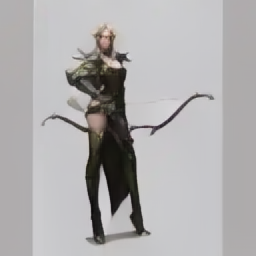

Found 12814 cached latents.
torch.Size([1, 32, 32, 8]) tensor(3) tensor([1, 2, 0, 0, 0, 3, 0, 0]) tensor(-0.7500) tensor(0.7500)


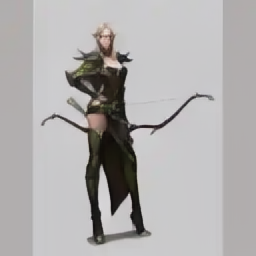

Found 12814 cached latents.
torch.Size([1, 32, 32, 8]) tensor(7) tensor([2, 4, 1, 0, 0, 7, 1, 1]) tensor(-0.8750) tensor(0.8750)


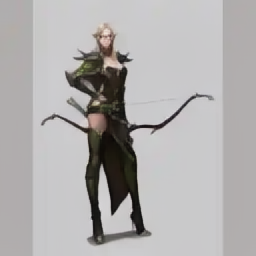

Found 12814 cached latents.
torch.Size([1, 32, 32, 8]) tensor(15) tensor([ 4,  9,  2,  1,  0, 15,  2,  3]) tensor(-0.9375) tensor(0.9375)


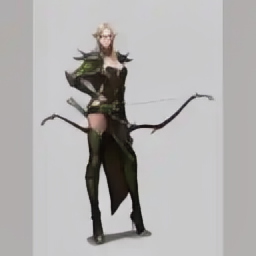

yay


In [24]:

for desired_bits in (1,2,3,4):
    ds = BitDataset(f'data/32x32x8latents/{dataset}/img',desired_bits)
    dl = DataLoader(ds)
    batch = next(iter(dl))
    latent = bit_codes_to_quantized_latent(batch,desired_bits)
    latent = einx.id("B H W C -> B C H W",latent)
    pq = autoencoder.post_quant(latent)
    ao = autoencoder.backbone.decode(pq)
    print(batch.shape, batch.max(), batch[0][0][0], latent.min(), latent.max())
    ipd.display(ih.tensor_to_pil(autoencoder.backbone.decode(autoencoder.post_quant(latent))[0]))
print("yay")
